In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LassoCV

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load processed data
X_train = pd.read_csv('../data/processed/regression/X_train.csv')
X_test = pd.read_csv('../data/processed/regression/X_test.csv')
y_train = pd.read_csv('../data/processed/regression/y_train.csv')
y_test = pd.read_csv('../data/processed/regression/y_test.csv')

X_reg = X_train.select_dtypes(include=[np.number])
y_reg = y_train['median_house_value']

In [3]:
num_cols = X_reg.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_reg.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [4]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.07, max_iter=20000, random_state=42))
])


lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)

## Explain L1 regularization and alpha

L1 regularization adds the absolute values of the coefficients as a penalty term to the loss function. \
This penalty encourages sparsity by shrinking some coefficients exactly to zero.

The alpha parameter controls the strength of the penalty:
- Larger alpha implies stronger regularization, with more coefficients driven to zero.
- Smaller alpha implies weaker regularization, and the model fits data more closely.

## Extracting and interpreting coefficients

In [5]:
feature_names = lasso_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = lasso_model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=lambda s: s.abs(), ascending=False)

zero_features = coef_df.loc[coef_df["coefficient"] == 0, "feature"]

print("Model coefficients:")
print(coef_df)

print("\nFeatures reduced to zero by Lasso:")
print(zero_features.tolist())

Model coefficients:
                            feature   coefficient
4               num__price_category  71885.778200
3                num__median_income  39804.034470
0                    num__longitude -15614.228630
1                     num__latitude -15178.476938
6            num__bedrooms_per_room  12425.500421
2           num__housing_median_age  10030.450383
5          num__rooms_per_household   4532.598923
7     num__population_per_household  -2227.857783
8  num__income_per_household_member    124.720806

Features reduced to zero by Lasso:
[]


## Model Evaluation

In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  38336.1386
MSE:  2836243995.4526
RMSE: 53256.3986
R²:   0.7757


R² = 0.776: This is quite solid. It means that the model explains about 78% of the variance in housing prices.

MAE of 38k and RMSE of 53k: Since median house values in this dataset are typically in the $150k–$500k range, the errors represent roughly 10–20% of the target values. While this is not perfect, it is reasonable for a baseline regression model.

The Lasso regression is helping with feature selection, but the relatively large error values suggest that the dataset’s nonlinear relationships (like latitude/longitude interactions or income brackets) aren’t being fully captured by a linear model.

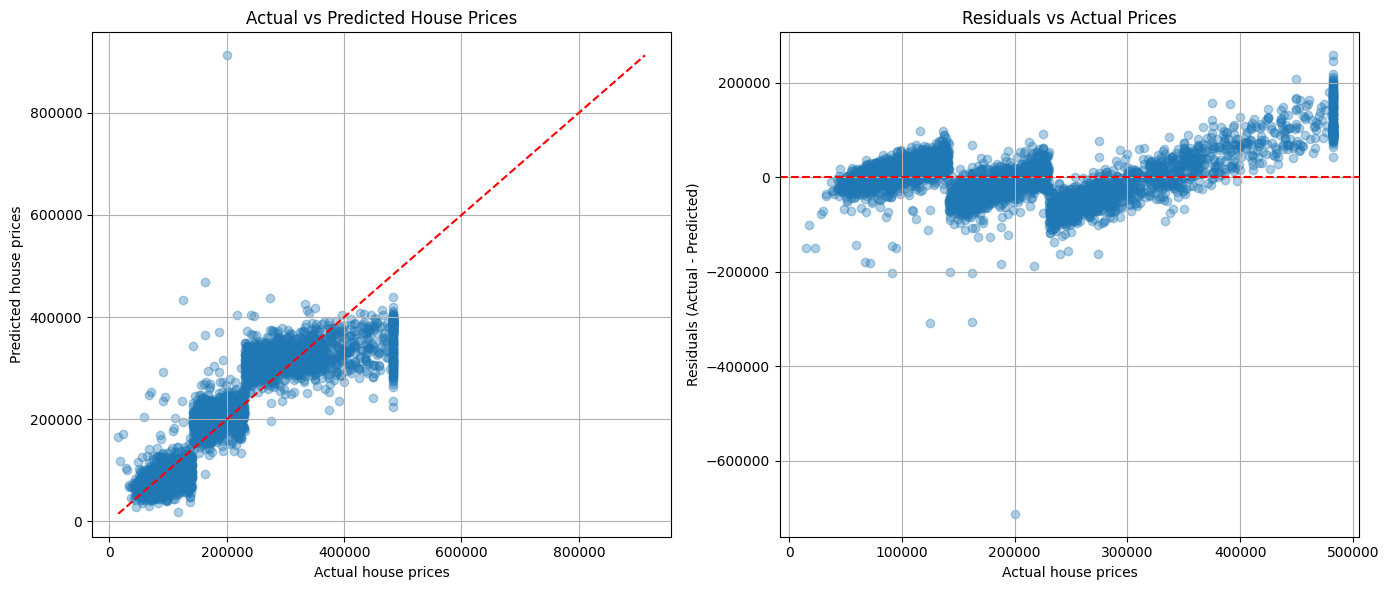

In [8]:
# Convert to 1D arrays
y_test_arr = np.asarray(y_test).ravel()
y_pred_arr = np.asarray(y_pred).ravel()

assert y_test_arr.shape == y_pred_arr.shape, f"Shape mismatch: {y_test_arr.shape} vs {y_pred_arr.shape}"

# Compute residuals
residuals = y_test_arr - y_pred_arr

# Plotting using arrays
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test_arr, y_pred_arr, alpha=0.35)
min_val = min(y_test_arr.min(), y_pred_arr.min())
max_val = max(y_test_arr.max(), y_pred_arr.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
axes[0].set_xlabel("Actual house prices")
axes[0].set_ylabel("Predicted house prices")
axes[0].set_title("Actual vs Predicted House Prices")
axes[0].grid(True)

# Residuals vs Actual
axes[1].scatter(y_test_arr, residuals, alpha=0.35)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Actual house prices")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals vs Actual Prices")
axes[1].grid(True)

plt.tight_layout()
plt.show()


The left plot (Actual vs Predicted House Prices) checks how close predictions are to actual values. \
The right plot reveals systematic bias, systematic underprediction and increasing error with price. \
Together the plots indicate the model generally follows the trend but tends to underpredict expensive houses and errors grow with price.

#### Interpreting Actual vs Predicted
- Points on the red dashed line mean perfect predictions.
- Tight clustering around the line implies a good overall fit.
- Systematic deviation from the line at high values implies model bias for expensive houses, and underprediction where points fall below the line.
- Spread away from the line measures error magnitude; larger vertical spread at higher actual prices means larger absolute errors at that price point (x-axis).

#### Residuals vs Actual
- Residual = Actual − Predicted. The points near 0 indicate accurate predictions.
- Pattern where residuals increase in magnitude with actual price indicates heteroscedasticity (variance of errors depends on price).
- Consistently positive residuals at high prices means the model underpredicts expensive homes.
- Clusters or curved patterns suggest missing nonlinear relationships or important features.

#### What these patterns imply
- Model misspecification: linear Lasso may not capture nonlinear effects (location interactions, income effects).
- Heteroscedastic errors: violates constant-variance assumption; RMSE/MAE will be dominated by errors in the higher priced properties.
- Leverage points: a few very expensive houses can distort fit and inflate RMSE.